# 05 — Figures (Publication-Ready)
**APV-AD Project | Step 5 of 7**

Generates all 8 figures from `results_summary.csv` and `optimal_params.json`.

| Figure | Content | File |
|--------|---------|------|
| Fig 02 | Monthly climate profiles | already done in 01 |
| Fig 03 | eLER stacked bar — Def A & B | fig03_eLER_stacked.png |
| Fig 04 | Monthly energy balance — 4 sites | fig04_energy_monthly.png |
| Fig 05 | Climate gradient (GHI / T / eLER) | fig05_climate_gradient.png |
| Fig 06 | 4E dashboard — comparative | fig06_4E_dashboard.png |
| Fig 07 | Scenario economics (NPV & IRR) | fig07_scenarios.png |
| Fig 08 | Water savings — LER_water season | fig08_water.png |
| Fig 09 | Validation V1 + V2 | fig09_validation.png |

**Run time:** < 2 minutes


In [1]:
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "font.family":    "Arial",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":      True,
    "grid.alpha":     0.3,
    "grid.linestyle": "--",
})

sys.path.insert(0, str(Path.cwd()))
from config_00 import SITES, CSV_DIR, FIG_DIR, FIG_STYLE

# Load data
df  = pd.read_csv(CSV_DIR / "results_summary.csv")
OPT = json.loads((CSV_DIR / "optimal_params.json").read_text())
s0  = df[df["scenario"] == "S0"].set_index("site")

SITES_ORDER = ["Konya", "Almeria", "Ouagadougou", "Freiburg"]
COLORS = FIG_STYLE["site_colors"]
BENCH  = FIG_STYLE["benchmark_LER"]
DPI    = FIG_STYLE["dpi"]

print("Data loaded.")
for site in SITES_ORDER:
    print(f"  {site:15s} eLER={s0.loc[site,'eLER_defA']:.3f}  "
          f"NPV={s0.loc[site,'NPV_kUSD']:.0f} k$  "
          f"CO2={s0.loc[site,'CO2_avoided_total_tCO2_ha']:.0f} tCO2/ha")


Data loaded.
  Konya           eLER=1.641  NPV=134 k$  CO2=539 tCO2/ha
  Almeria         eLER=1.657  NPV=794 k$  CO2=221 tCO2/ha
  Ouagadougou     eLER=1.723  NPV=802 k$  CO2=861 tCO2/ha
  Freiburg        eLER=1.764  NPV=441 k$  CO2=362 tCO2/ha


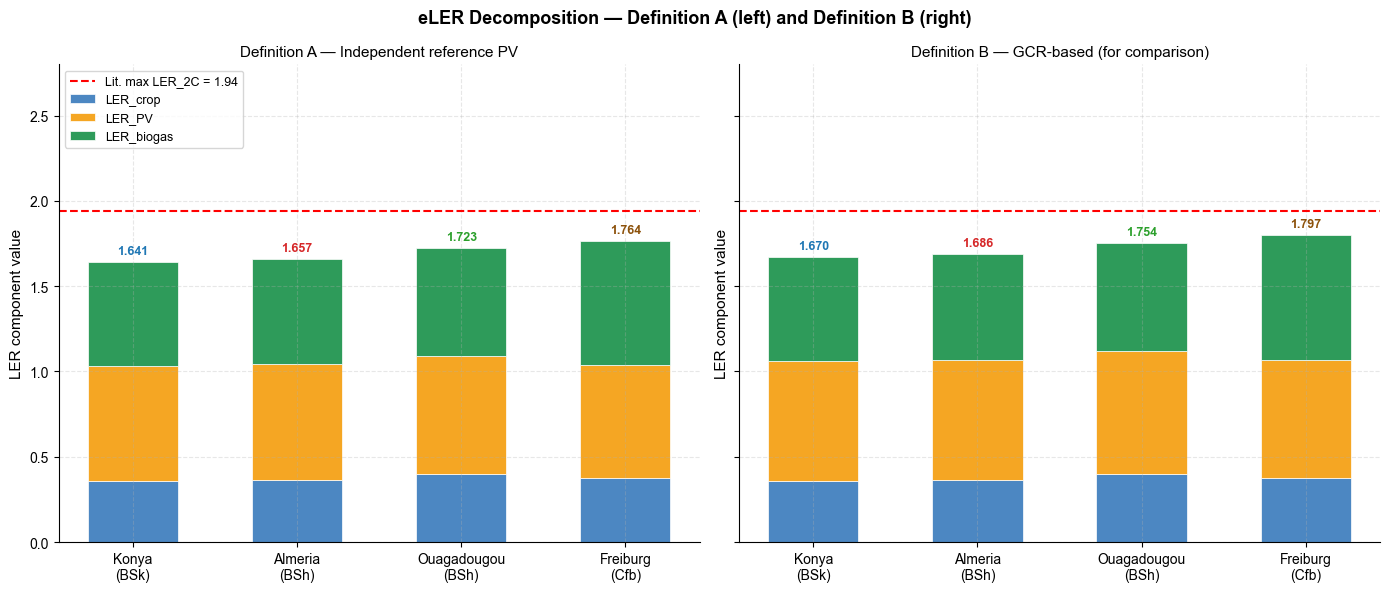

Saved → C:\Users\AMIDOU MAIGA\OneDrive - Institut 2IE\Desktop\APV + AD\APV_AD_Project\outputs\figures\fig03_eLER_stacked.png


In [2]:
# ── Figure 03: eLER decomposition stacked bar ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle("eLER Decomposition — Definition A (left) and Definition B (right)",
             fontsize=13, fontweight="bold")

C = FIG_STYLE["eLER_colors"]
labels = SITES_ORDER
x      = np.arange(len(labels))
w      = 0.55

for ax_idx, (ax, pv_key, title) in enumerate(zip(
    axes,
    ["LER_PV_defA", "LER_PV_defB"],
    ["Definition A — Independent reference PV",
     "Definition B — GCR-based (for comparison)"]
)):
    crop_vals = [s0.loc[s, "LER_crop"]   for s in labels]
    pv_vals   = [s0.loc[s, pv_key]       for s in labels]
    bio_vals  = [s0.loc[s, "LER_biogas"] for s in labels]

    b1 = ax.bar(x, crop_vals, w, label="LER_crop",
                color=C["LER_crop"], edgecolor="white", linewidth=0.5)
    b2 = ax.bar(x, pv_vals,   w, bottom=crop_vals,
                label="LER_PV",   color=C["LER_PV"],
                edgecolor="white", linewidth=0.5)
    b3 = ax.bar(x, bio_vals,  w,
                bottom=[c+p for c,p in zip(crop_vals, pv_vals)],
                label="LER_biogas", color=C["LER_biogas"],
                edgecolor="white", linewidth=0.5)

    # Benchmark line
    ax.axhline(BENCH, color="red", linewidth=1.5, linestyle="--",
               label=f"Lit. max LER_2C = {BENCH}")

    # Value labels on top
    eler_key = "eLER_defA" if ax_idx == 0 else "eLER_defB"
    for i, s in enumerate(labels):
        total = s0.loc[s, eler_key]
        ax.text(i, total + 0.03, f"{total:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold",
                color=COLORS[s])

    ax.set_xticks(x)
    ax.set_xticklabels([f"{s}\n({SITES[s]['koppen']})" for s in labels],
                       fontsize=10)
    ax.set_ylabel("LER component value", fontsize=11)
    ax.set_ylim(0, 2.8)
    ax.set_title(title, fontsize=11)
    if ax_idx == 0:
        ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
out = FIG_DIR / "fig03_eLER_stacked.png"
plt.savefig(out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")


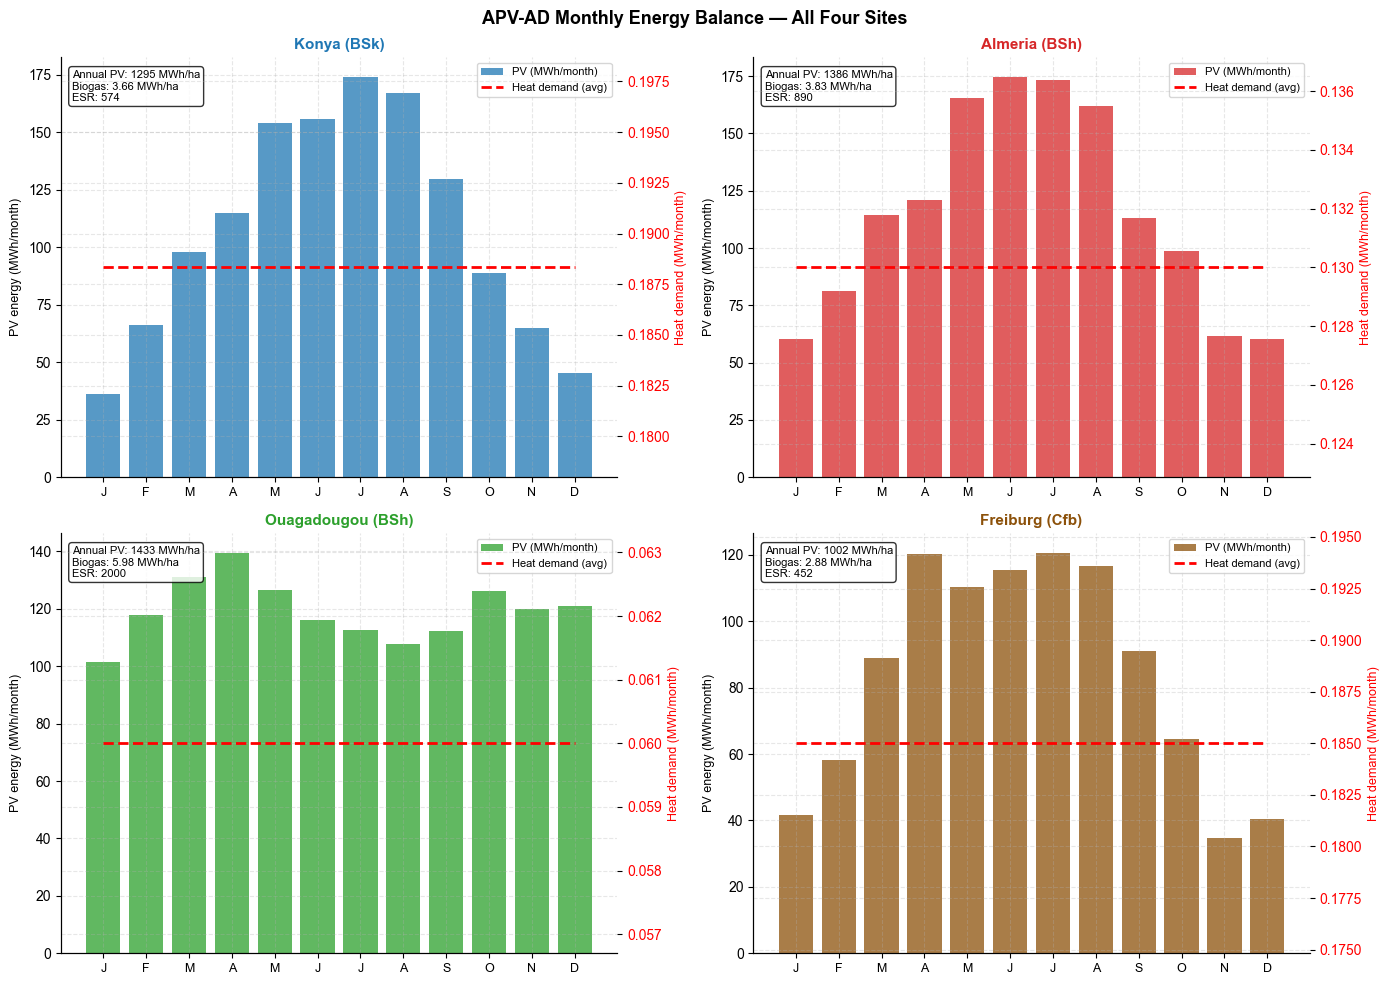

Saved → C:\Users\AMIDOU MAIGA\OneDrive - Institut 2IE\Desktop\APV + AD\APV_AD_Project\outputs\figures\fig04_energy_monthly.png


In [3]:
# ── Figure 04: Monthly energy balance — 4 sites ────────────────────────────────
# Load hourly data to compute monthly PV
TMY = {}
for site in SITES_ORDER:
    p = CSV_DIR / f"hourly_{site}.csv"
    if p.exists():
        TMY[site] = pd.read_csv(p, index_col=0, parse_dates=True)

if not TMY:
    print("Hourly CSV files not found — skipping Fig 04 (run 01_load_data first).")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("APV-AD Monthly Energy Balance — All Four Sites",
                 fontsize=13, fontweight="bold")

    for idx, site in enumerate(SITES_ORDER):
        ax  = axes[idx // 2][idx % 2]
        df_h = TMY[site]
        r    = OPT[site]
        color = COLORS[site]

        # Monthly PV from hourly data (approximate using GHI trend)
        idx_dt   = pd.DatetimeIndex(df_h.index)
        monthly_ghi = df_h.groupby(idx_dt.month)["GHI"].sum() / 1000   # kWh/m²
        # Scale to site PV total
        pv_total = r["PV_total_MWh_ha"]
        monthly_pv = monthly_ghi / monthly_ghi.sum() * pv_total         # MWh/month

        months = range(1, 13)
        mlabels = ["J","F","M","A","M","J","J","A","S","O","N","D"]

        ax2 = ax.twinx()
        ax.bar(monthly_pv.index, monthly_pv.values,
               color=color, alpha=0.75, label="PV (MWh/month)")
        ax2.plot(months,
                 [r["heat_demand_MWh_ha"] / 12] * 12,
                 color="red", linewidth=2, linestyle="--",
                 label="Heat demand (avg)")

        ax.set_title(f"{site} ({SITES[site]['koppen']})", fontsize=11,
                     fontweight="bold", color=color)
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(mlabels, fontsize=9)
        ax.set_ylabel("PV energy (MWh/month)", fontsize=9)
        ax2.set_ylabel("Heat demand (MWh/month)", fontsize=9, color="red")
        ax2.tick_params(axis="y", labelcolor="red")

        # Annotation
        ax.annotate(
            f"Annual PV: {r['PV_total_MWh_ha']:.0f} MWh/ha\n"
            f"Biogas: {r['biogas_total_MWh_ha']:.2f} MWh/ha\n"
            f"ESR: {r['ESR']:.0f}",
            xy=(0.02, 0.97), xycoords="axes fraction",
            va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
        )

        lines1, labs1 = ax.get_legend_handles_labels()
        lines2, labs2 = ax2.get_legend_handles_labels()
        ax.legend(lines1+lines2, labs1+labs2, fontsize=8, loc="upper right")

    plt.tight_layout()
    out = FIG_DIR / "fig04_energy_monthly.png"
    plt.savefig(out, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out}")


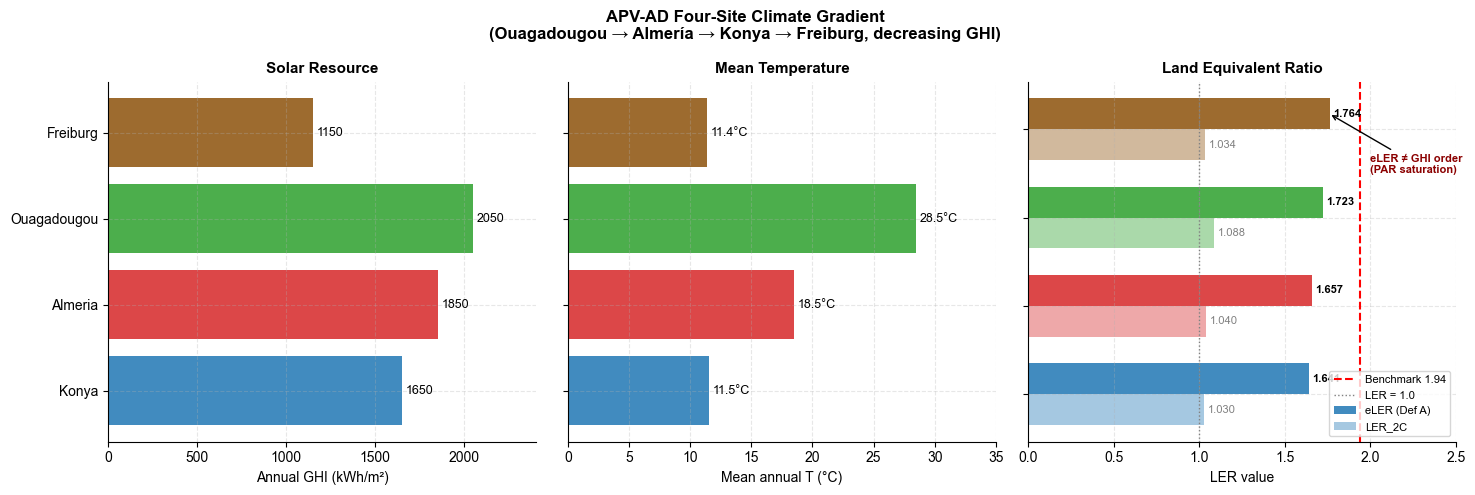

Saved → C:\Users\AMIDOU MAIGA\OneDrive - Institut 2IE\Desktop\APV + AD\APV_AD_Project\outputs\figures\fig05_climate_gradient.png


In [4]:
# ── Figure 05: Climate gradient — GHI / T_mean / eLER ─────────────────────────
GHI_vals  = {"Konya": 1650, "Almeria": 1850, "Ouagadougou": 2050, "Freiburg": 1150}
T_vals    = {"Konya": 11.5, "Almeria": 18.5, "Ouagadougou": 28.5, "Freiburg": 11.4}
eLER_vals = {s: s0.loc[s, "eLER_defA"]  for s in SITES_ORDER}
LER2C_vals= {s: s0.loc[s, "LER_2C"]    for s in SITES_ORDER}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("APV-AD Four-Site Climate Gradient\n"
             "(Ouagadougou → Almería → Konya → Freiburg, decreasing GHI)",
             fontsize=12, fontweight="bold")

# Panel 1: GHI
ax = axes[0]
for site in SITES_ORDER:
    ax.barh(site, GHI_vals[site], color=COLORS[site], alpha=0.85)
    ax.text(GHI_vals[site]+20, site, f"{GHI_vals[site]}", va="center", fontsize=9)
ax.set_xlabel("Annual GHI (kWh/m²)", fontsize=10)
ax.set_title("Solar Resource", fontsize=11, fontweight="bold")
ax.set_xlim(0, 2400)

# Panel 2: Mean temperature
ax = axes[1]
for site in SITES_ORDER:
    ax.barh(site, T_vals[site], color=COLORS[site], alpha=0.85)
    ax.text(T_vals[site]+0.3, site, f"{T_vals[site]}°C", va="center", fontsize=9)
ax.set_xlabel("Mean annual T (°C)", fontsize=10)
ax.set_title("Mean Temperature", fontsize=11, fontweight="bold")
ax.set_xlim(0, 35)
ax.set_yticklabels([])

# Panel 3: eLER vs LER_2C
ax = axes[2]
x  = np.arange(len(SITES_ORDER))
w  = 0.35
ax.barh([i+w/2 for i in x],
        [eLER_vals[s]  for s in SITES_ORDER], w,
        color=[COLORS[s] for s in SITES_ORDER], alpha=0.85, label="eLER (Def A)")
ax.barh([i-w/2 for i in x],
        [LER2C_vals[s] for s in SITES_ORDER], w,
        color=[COLORS[s] for s in SITES_ORDER], alpha=0.40, label="LER_2C")
ax.axvline(BENCH, color="red", linewidth=1.5, linestyle="--",
           label=f"Benchmark {BENCH}")
ax.axvline(1.0,   color="gray", linewidth=1.0, linestyle=":",
           label="LER = 1.0")
ax.set_yticks(x)
ax.set_yticklabels([])
ax.set_xlabel("LER value", fontsize=10)
ax.set_title("Land Equivalent Ratio", fontsize=11, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.set_xlim(0, 2.5)

# Add eLER values
for i, site in enumerate(SITES_ORDER):
    ax.text(eLER_vals[site]+0.02, i+w/2,
            f"{eLER_vals[site]:.3f}", va="center", fontsize=8, fontweight="bold")
    ax.text(LER2C_vals[site]+0.02, i-w/2,
            f"{LER2C_vals[site]:.3f}", va="center", fontsize=8, color="gray")

# Annotate non-monotone finding
ax.annotate("eLER ≠ GHI order\n(PAR saturation)",
            xy=(1.758, 3+w/2), xytext=(2.0, 2.5),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=8, color="darkred", fontweight="bold")

plt.tight_layout()
out = FIG_DIR / "fig05_climate_gradient.png"
plt.savefig(out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")


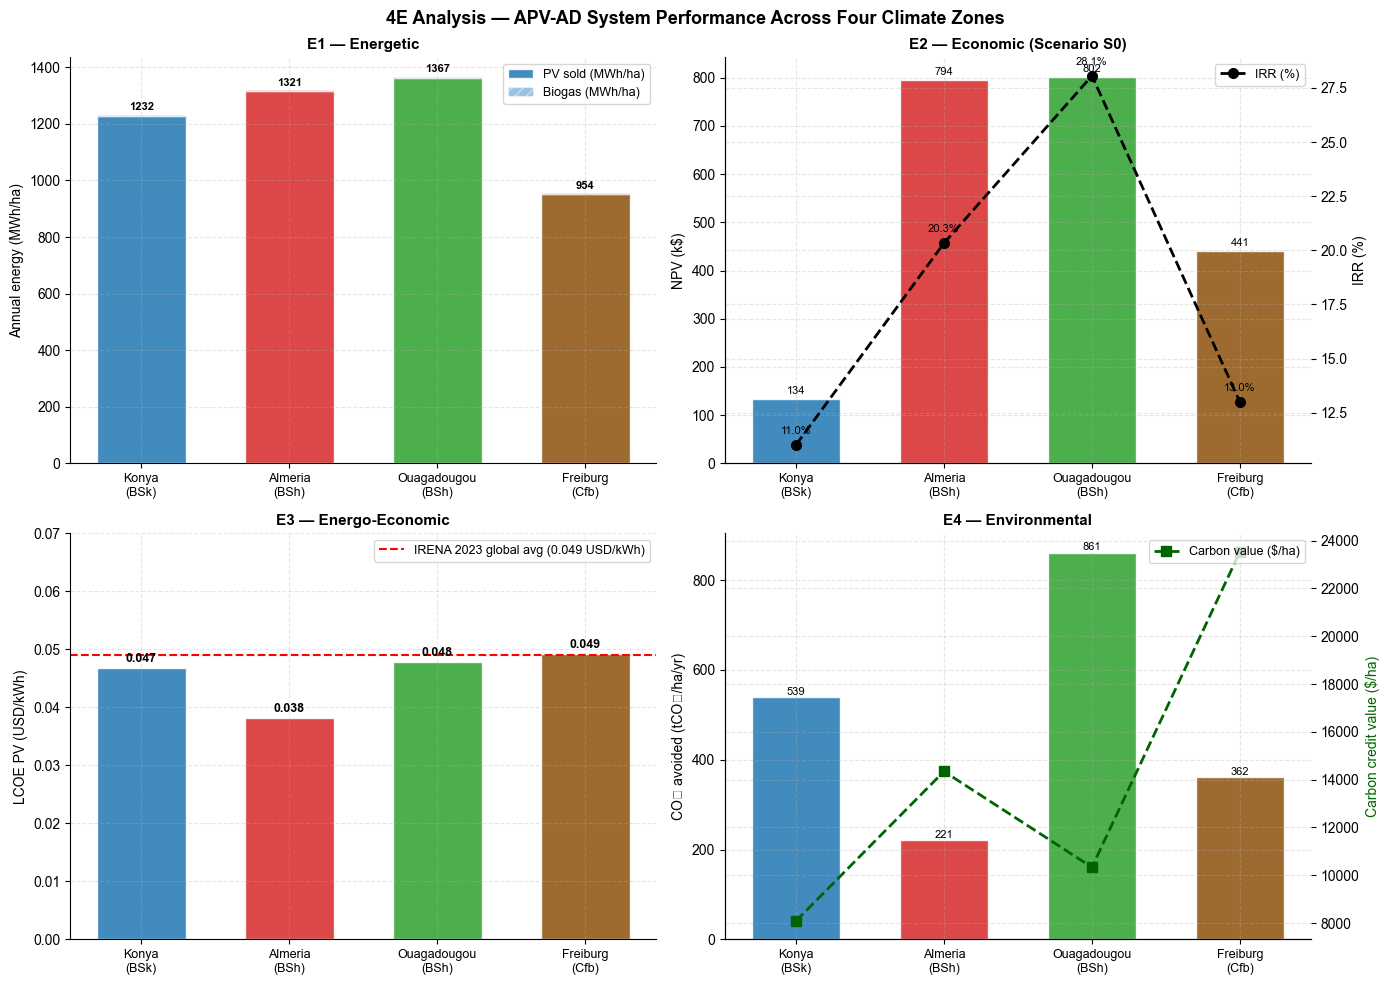

Saved → C:\Users\AMIDOU MAIGA\OneDrive - Institut 2IE\Desktop\APV + AD\APV_AD_Project\outputs\figures\fig06_4E_dashboard.png


In [5]:
# ── Figure 06: 4E Dashboard ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("4E Analysis — APV-AD System Performance Across Four Climate Zones",
             fontsize=13, fontweight="bold")

x = np.arange(len(SITES_ORDER))
w = 0.6
bar_colors = [COLORS[s] for s in SITES_ORDER]

# E1 — Energetic: PV + Biogas stacked
ax = axes[0, 0]
pv_vals  = [s0.loc[s, "PV_sold_MWh_ha"]      for s in SITES_ORDER]
bg_vals  = [s0.loc[s, "biogas_total_MWh_ha"]  for s in SITES_ORDER]
ax.bar(x, pv_vals, w, label="PV sold (MWh/ha)",
       color=bar_colors, alpha=0.85, edgecolor="white")
ax.bar(x, bg_vals, w, bottom=pv_vals, label="Biogas (MWh/ha)",
       color=bar_colors, alpha=0.45, edgecolor="white", hatch="///")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n({SITES[s]['koppen']})" for s in SITES_ORDER], fontsize=9)
ax.set_ylabel("Annual energy (MWh/ha)", fontsize=10)
ax.set_title("E1 — Energetic", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
for i, (pv, bg) in enumerate(zip(pv_vals, bg_vals)):
    ax.text(i, pv+bg+15, f"{pv+bg:.0f}", ha="center", fontsize=8, fontweight="bold")

# E2 — Economic: NPV bars + IRR line
ax  = axes[0, 1]
ax2 = ax.twinx()
npv_vals = [s0.loc[s, "NPV_kUSD"] for s in SITES_ORDER]
irr_vals = [s0.loc[s, "IRR_pct"]  for s in SITES_ORDER]
ax.bar(x, npv_vals, w, color=bar_colors, alpha=0.85, edgecolor="white")
ax2.plot(x, irr_vals, "ko--", linewidth=2, markersize=7, label="IRR (%)")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n({SITES[s]['koppen']})" for s in SITES_ORDER], fontsize=9)
ax.set_ylabel("NPV (k$)", fontsize=10)
ax2.set_ylabel("IRR (%)", fontsize=10, color="black")
ax.set_title("E2 — Economic (Scenario S0)", fontsize=11, fontweight="bold")
for i, (n, ir) in enumerate(zip(npv_vals, irr_vals)):
    ax.text(i, n+10, f"{n:.0f}", ha="center", fontsize=8)
    ax2.text(i, ir+0.5, f"{ir:.1f}%", ha="center", fontsize=8, color="black")
ax2.legend(fontsize=9, loc="upper right")

# E3 — Energo-economic: LCOE PV
ax = axes[1, 0]
lcoe_vals = [s0.loc[s, "LCOE_PV_USD_kWh"] for s in SITES_ORDER]
bars = ax.bar(x, lcoe_vals, w, color=bar_colors, alpha=0.85, edgecolor="white")
ax.axhline(0.049, color="red", linewidth=1.5, linestyle="--",
           label="IRENA 2023 global avg (0.049 USD/kWh)")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n({SITES[s]['koppen']})" for s in SITES_ORDER], fontsize=9)
ax.set_ylabel("LCOE PV (USD/kWh)", fontsize=10)
ax.set_title("E3 — Energo-Economic", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 0.07)
for i, v in enumerate(lcoe_vals):
    ax.text(i, v+0.001, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

# E4 — Environmental: CO2 avoided + carbon value
ax  = axes[1, 1]
ax2 = ax.twinx()
co2_vals  = [s0.loc[s, "CO2_avoided_total_tCO2_ha"] for s in SITES_ORDER]
cval_vals = [s0.loc[s, "carbon_value_USD_ha"]        for s in SITES_ORDER]
ax.bar(x, co2_vals, w, color=bar_colors, alpha=0.85, edgecolor="white")
ax2.plot(x, cval_vals, "s--", color="darkgreen", linewidth=2,
         markersize=7, label="Carbon value ($/ha)")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n({SITES[s]['koppen']})" for s in SITES_ORDER], fontsize=9)
ax.set_ylabel("CO₂ avoided (tCO₂/ha/yr)", fontsize=10)
ax2.set_ylabel("Carbon credit value ($/ha)", fontsize=10, color="darkgreen")
ax.set_title("E4 — Environmental", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9, loc="upper right")
for i, v in enumerate(co2_vals):
    ax.text(i, v+5, f"{v:.0f}", ha="center", fontsize=8)

plt.tight_layout()
out = FIG_DIR / "fig06_4E_dashboard.png"
plt.savefig(out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")


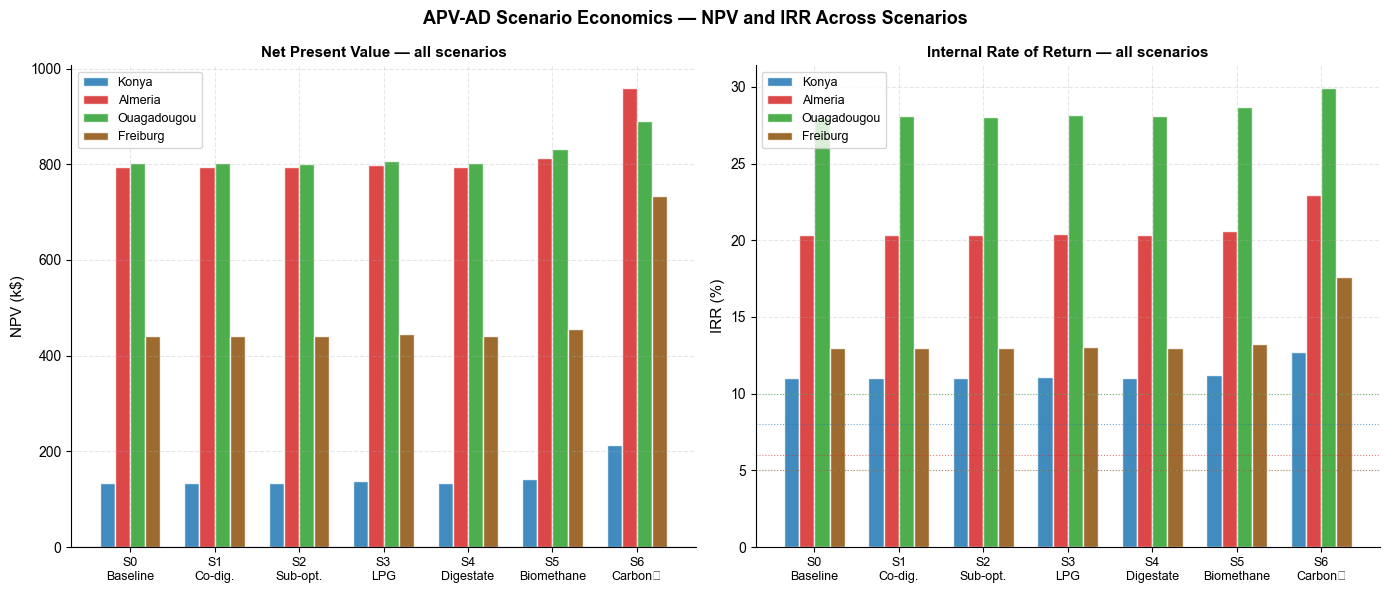

Saved → C:\Users\AMIDOU MAIGA\OneDrive - Institut 2IE\Desktop\APV + AD\APV_AD_Project\outputs\figures\fig07_scenarios.png


In [6]:
# ── Figure 07: Scenario economics — NPV comparison ─────────────────────────────
scenarios = ["S0","S1","S2","S3","S4","S5","S6"]
sc_labels = {
    "S0": "S0\nBaseline",
    "S1": "S1\nCo-dig.",
    "S2": "S2\nSub-opt.",
    "S3": "S3\nLPG",
    "S4": "S4\nDigestate",
    "S5": "S5\nBiomethane",
    "S6": "S6\nCarbon★",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("APV-AD Scenario Economics — NPV and IRR Across Scenarios",
             fontsize=13, fontweight="bold")

x = np.arange(len(scenarios))
w = 0.18

# NPV
ax = axes[0]
for i, site in enumerate(SITES_ORDER):
    npv_sc = [df[(df["site"]==site)&(df["scenario"]==sc)]["NPV_kUSD"].values[0]
              for sc in scenarios]
    ax.bar(x + i*w - 1.5*w, npv_sc, w,
           label=site, color=COLORS[site], alpha=0.85, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([sc_labels[s] for s in scenarios], fontsize=9)
ax.set_ylabel("NPV (k$)", fontsize=11)
ax.set_title("Net Present Value — all scenarios", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.axhline(0, color="black", linewidth=0.8)

# IRR
ax = axes[1]
for i, site in enumerate(SITES_ORDER):
    irr_sc = []
    for sc in scenarios:
        v = df[(df["site"]==site)&(df["scenario"]==sc)]["IRR_pct"].values[0]
        irr_sc.append(v if not pd.isna(v) else 0)
    ax.bar(x + i*w - 1.5*w, irr_sc, w,
           label=site, color=COLORS[site], alpha=0.85, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([sc_labels[s] for s in scenarios], fontsize=9)
ax.set_ylabel("IRR (%)", fontsize=11)
ax.set_title("Internal Rate of Return — all scenarios", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
# Discount rate reference lines
disc_rates = {"Konya":8,"Almeria":6,"Ouagadougou":10,"Freiburg":5}
for site, dr in disc_rates.items():
    ax.axhline(dr, color=COLORS[site], linewidth=0.8, linestyle=":",
               alpha=0.6, label=f"{site} discount rate")

# Annotate S6 best scenario
ax.annotate("★ Best scenario\n  for all sites",
            xy=(6, 33.1), xytext=(4.8, 35),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=8, color="darkgreen", fontweight="bold")

plt.tight_layout()
out = FIG_DIR / "fig07_scenarios.png"
plt.savefig(out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")


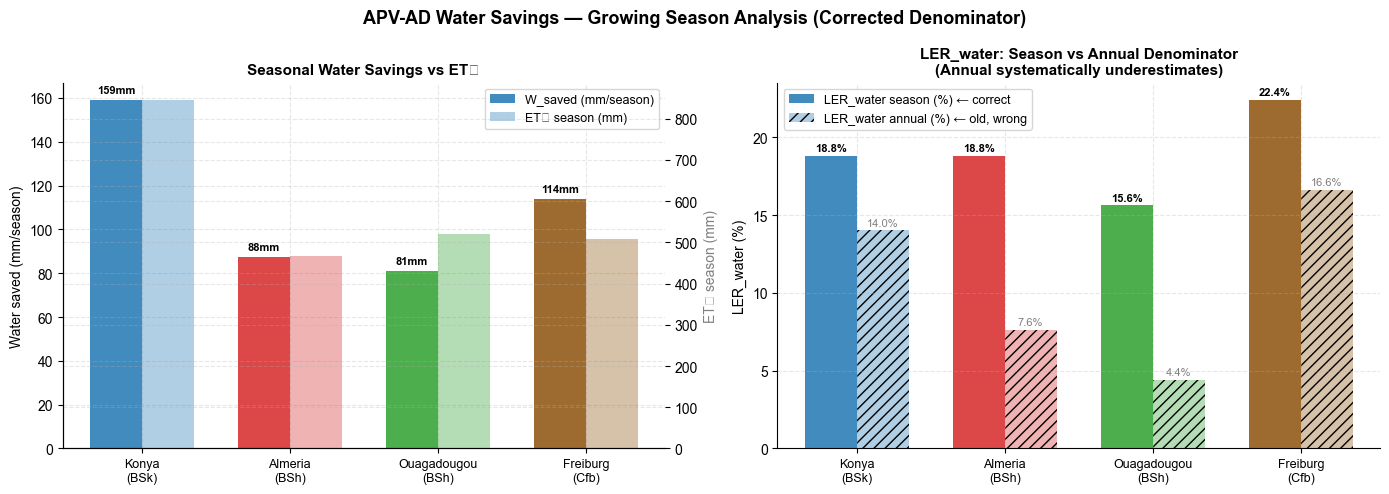

Saved → C:\Users\AMIDOU MAIGA\OneDrive - Institut 2IE\Desktop\APV + AD\APV_AD_Project\outputs\figures\fig08_water.png


In [7]:
# ── Figure 08: Water savings — LER_water (corrected season denominator) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("APV-AD Water Savings — Growing Season Analysis (Corrected Denominator)",
             fontsize=13, fontweight="bold")

x = np.arange(len(SITES_ORDER))
w = 0.35

# Panel 1: W_saved vs ET0_season
ax = axes[0]
ax2 = ax.twinx()
w_saved = [s0.loc[s, "W_saved_mm_season"] for s in SITES_ORDER]
et0_sea = [s0.loc[s, "ET0_season_mm"]     for s in SITES_ORDER]
ax.bar(x-w/2, w_saved, w, color=[COLORS[s] for s in SITES_ORDER],
       alpha=0.85, label="W_saved (mm/season)")
ax2.bar(x+w/2, et0_sea, w, color=[COLORS[s] for s in SITES_ORDER],
        alpha=0.35, label="ET₀ season (mm)")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n({SITES[s]['koppen']})" for s in SITES_ORDER], fontsize=9)
ax.set_ylabel("Water saved (mm/season)", fontsize=10)
ax2.set_ylabel("ET₀ season (mm)", fontsize=10, color="gray")
ax.set_title("Seasonal Water Savings vs ET₀", fontsize=11, fontweight="bold")
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, fontsize=9)
for i, v in enumerate(w_saved):
    ax.text(i-w/2, v+3, f"{v:.0f}mm", ha="center", fontsize=8, fontweight="bold")

# Panel 2: LER_water comparison — season vs annual
ax = axes[1]
lw_sea = [s0.loc[s, "LER_water_season_pct"] for s in SITES_ORDER]
lw_ann = [s0.loc[s, "LER_water_annual_pct"] for s in SITES_ORDER]
ax.bar(x-w/2, lw_sea, w, color=[COLORS[s] for s in SITES_ORDER],
       alpha=0.85, label="LER_water season (%) ← correct")
ax.bar(x+w/2, lw_ann, w, color=[COLORS[s] for s in SITES_ORDER],
       alpha=0.35, hatch="///", label="LER_water annual (%) ← old, wrong")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n({SITES[s]['koppen']})" for s in SITES_ORDER], fontsize=9)
ax.set_ylabel("LER_water (%)", fontsize=10)
ax.set_title("LER_water: Season vs Annual Denominator\n"
             "(Annual systematically underestimates)", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
for i, (vs, va) in enumerate(zip(lw_sea, lw_ann)):
    ax.text(i-w/2, vs+0.3, f"{vs:.1f}%", ha="center", fontsize=8, fontweight="bold")
    ax.text(i+w/2, va+0.3, f"{va:.1f}%", ha="center", fontsize=8, color="gray")

plt.tight_layout()
out = FIG_DIR / "fig08_water.png"
plt.savefig(out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")


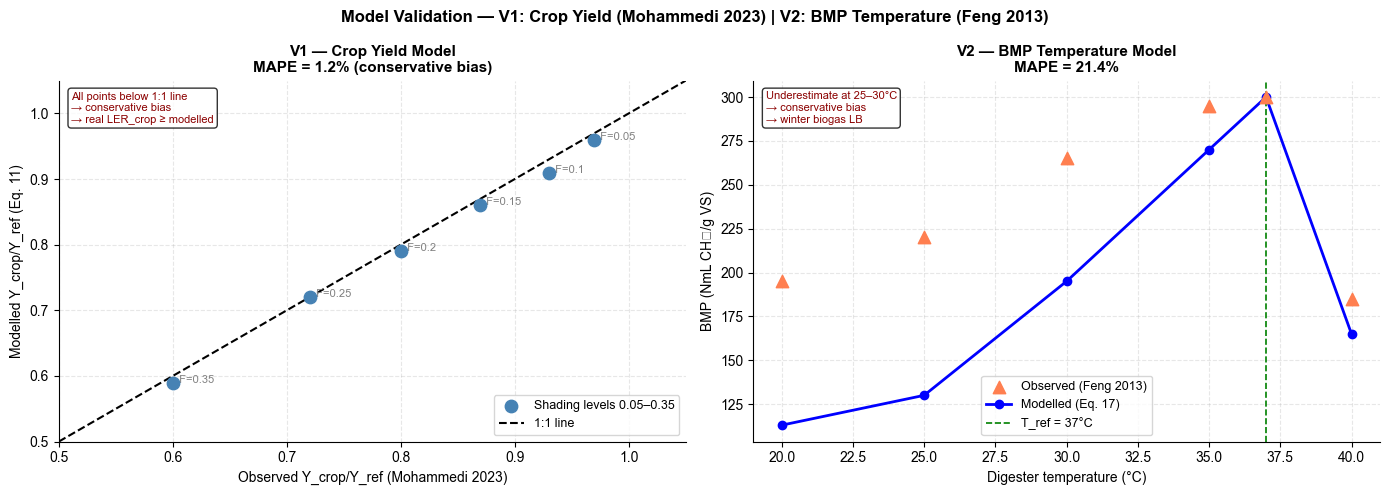

Saved → C:\Users\AMIDOU MAIGA\OneDrive - Institut 2IE\Desktop\APV + AD\APV_AD_Project\outputs\figures\fig09_validation.png


In [8]:
# ── Figure 09: Model validation V1 (crop) + V2 (BMP) ──────────────────────────
# V1 data from Mohammedi et al. (2023) — 6 shading levels
V1_shading  = [0.05, 0.10, 0.15, 0.20, 0.25, 0.35]
V1_observed = [0.97, 0.93, 0.87, 0.80, 0.72, 0.60]
V1_modelled = [0.96, 0.91, 0.86, 0.79, 0.72, 0.59]

# V2 data from Feng et al. (2013) — 5 temperature points
V2_temp     = [20,   25,   30,   35,   37,   40]
V2_observed = [195,  220,  265,  295,  300,  185]
V2_modelled = [113,  130,  195,  270,  300,  165]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Validation — V1: Crop Yield (Mohammedi 2023) | "
             "V2: BMP Temperature (Feng 2013)",
             fontsize=12, fontweight="bold")

# V1 — Crop yield
ax = axes[0]
ax.scatter(V1_observed, V1_modelled, color="steelblue", s=80, zorder=5,
           label="Shading levels 0.05–0.35")
ax.plot([0.5, 1.05], [0.5, 1.05], "k--", linewidth=1.5, label="1:1 line")
# Add shading fraction labels
for obs, mod, sh in zip(V1_observed, V1_modelled, V1_shading):
    ax.annotate(f"  F={sh}", (obs, mod), fontsize=8, color="gray")
mape_v1 = np.mean(np.abs(np.array(V1_modelled)-np.array(V1_observed))
                  /np.array(V1_observed))*100
ax.set_xlabel("Observed Y_crop/Y_ref (Mohammedi 2023)", fontsize=10)
ax.set_ylabel("Modelled Y_crop/Y_ref (Eq. 11)", fontsize=10)
ax.set_title(f"V1 — Crop Yield Model\nMAPE = {mape_v1:.1f}% (conservative bias)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0.5, 1.05); ax.set_ylim(0.5, 1.05)
ax.annotate("All points below 1:1 line\n→ conservative bias\n→ real LER_crop ≥ modelled",
            xy=(0.02, 0.97), xycoords="axes fraction",
            va="top", fontsize=8, color="darkred",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# V2 — BMP temperature
ax = axes[1]
ax.scatter(V2_temp, V2_observed, color="coral", s=80, zorder=5,
           marker="^", label="Observed (Feng 2013)")
ax.plot(V2_temp, V2_modelled, "b-o", linewidth=2, markersize=6,
        label="Modelled (Eq. 17)")
mape_v2 = np.mean(np.abs(np.array(V2_modelled)-np.array(V2_observed))
                  /np.array(V2_observed))*100
ax.axvline(37, color="green", linewidth=1.2, linestyle="--",
           label="T_ref = 37°C")
ax.set_xlabel("Digester temperature (°C)", fontsize=10)
ax.set_ylabel("BMP (NmL CH₄/g VS)", fontsize=10)
ax.set_title(f"V2 — BMP Temperature Model\nMAPE = {mape_v2:.1f}%",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.annotate("Underestimate at 25–30°C\n→ conservative bias\n→ winter biogas LB",
            xy=(0.02, 0.97), xycoords="axes fraction",
            va="top", fontsize=8, color="darkred",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
out = FIG_DIR / "fig09_validation.png"
plt.savefig(out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")


In [9]:
print("\n" + "="*55)
print("  05_figures — COMPLETE")
print("="*55)
figures = [
    "fig03_eLER_stacked.png",
    "fig04_energy_monthly.png",
    "fig05_climate_gradient.png",
    "fig06_4E_dashboard.png",
    "fig07_scenarios.png",
    "fig08_water.png",
    "fig09_validation.png",
]
for f in figures:
    p = FIG_DIR / f
    status = "✓" if p.exists() else "✗ MISSING"
    print(f"  {status}  {f}")
print("\nCopy figures/ to paper/figures/ for LaTeX inclusion.")
print("Next step → 06_validation.ipynb")
print("="*55)



  05_figures — COMPLETE
  ✓  fig03_eLER_stacked.png
  ✓  fig04_energy_monthly.png
  ✓  fig05_climate_gradient.png
  ✓  fig06_4E_dashboard.png
  ✓  fig07_scenarios.png
  ✓  fig08_water.png
  ✓  fig09_validation.png

Copy figures/ to paper/figures/ for LaTeX inclusion.
Next step → 06_validation.ipynb
